# Подключаем библиотеки и смотрим на датасет с запросами к Яндекс.Картинкам

In [1]:
import pandas as pd 
import pandasql as ps
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.optimize import curve_fit

In [2]:
# путь до файла
file_path = '/home/neubauten2/Downloads/data.tsv'

# задаем в ручную названия столбов
df = pd.read_csv(file_path, sep='\t', header=None, names=['text', 'timestamp', 'platform'])

rows, columns = df.shape
print(f"Строк: {rows}, Столбцов: {columns}")
print(f"Записей в desktop (из общего): {len(df[df['platform'] == 'desktop'])}")
print(f"Записей в touch (из общего): {len(df[df['platform'] == 'touch'])}")

# переводим timestamp в дату
df["date"] = pd.to_datetime(df["timestamp"], unit="s")

# Создаём соединение с SQLite в памяти
conn = sqlite3.connect(":memory:")

Строк: 1114365, Столбцов: 3
Записей в desktop (из общего): 388264
Записей в touch (из общего): 726101


In [3]:
# Записываем DataFrame в таблицу queries
df.to_sql("queries", conn, index=False, if_exists="replace")


# Посмотрим содержимое
query = """
SELECT text, date, platform
FROM queries
"""

df = pd.read_sql(query, conn) 
df.head(10)

,text,date,platform
0,малевич картины,2021-09-16 15:34:25,desktop
1,психология,2021-09-16 08:39:43,touch
2,с днём рождения лена,2021-09-16 05:52:43,touch
3,зверополис фильмы,2021-09-16 10:19:59,touch
4,алабай собака фото,2021-09-16 10:04:05,touch
5,бактериофаг,2021-09-16 18:16:42,desktop
6,полина гагарина,2021-09-16 14:53:25,touch
7,кадр из фильма,2021-09-16 05:40:37,desktop
8,погода,2021-09-16 08:25:41,touch
9,кухни дизайн,2021-09-16 17:37:01,touch


# Задание 1 — Диапазон дат¶

### Необходимо определить, за какой период предоставлены данные. Для этого находим минимальную и максимальную дату в датасете data.tsv.

In [4]:
#Запрос на отбор дат + время
date_time = """
SELECT MIN(date) as min_date,
       MAX(date) as max_date
FROM queries
"""

#формируем датафрейм,
#если нужно только время, то оставляем первые 10 символов
df_1 = pd.read_sql(date_time, conn) 

edge_days = f'Дата начала: {df_1.iloc[0, 0][:10]},  Дата конца: {df_1.iloc[0, 1][:10]}'

date_start = pd.to_datetime(df_1.iloc[0, 0][:10])
date_end = pd.to_datetime(df_1.iloc[0, 1][:10])
#сколько дней запросы 
days_between = (date_end - date_start).days + 1
print(f"Период с {date_start} по {date_end}")
print(f"Всего затронуто календарных дней: {days_between}")
print(f"\nОсобенности выборки:")
print(f"  • Первый день неполный: первая запись в {df_1.iloc[0, 0]}")
print(f"  • Последний день неполный: последняя запись в {df_1.iloc[0, 1]}")

Период с 2021-08-31 00:00:00 по 2021-09-21 00:00:00
Всего затронуто календарных дней: 22

Особенности выборки:
  • Первый день неполный: первая запись в 2021-08-31 21:00:00
  • Последний день неполный: последняя запись в 2021-09-21 20:59:59


# Задание 2 — Количество запросов с текстом "ютуб" по платформам

### Фильтруем строки, где text содержит подстроку "ютуб" или "youtube", независимо от регистра группируем по колонке platform и считаем количество запросов для каждой из них (desktop, touch).

### Для более подробного анализа можно воспользоваться нечетким поиском - fuzzy search.

In [5]:
#Запрос для отбора независимо от регистра имользуем функцию LOWER
youtube = """
SELECT platform,
       COUNT(*) as count
from queries
where LOWER(text) LIKE LOWER('%ютуб%') OR  LOWER(text) LIKE LOWER('%youtube%')
group by platform
"""

#формируем датафрейм,
df_2 = pd.read_sql(youtube, conn) 
display(df_2.style.hide(axis="index"))

print(f'Первоначальный анализ показывает, что на desctop запрос youtube ищут больше в {round(df_2.iloc[0,1]/df_2.iloc[1,1], 2)} раза.')
print('Т.к. в запросах могут быть очепятки, то для более подробного анализа можно воспользоваться нечетким поиском - fuzzy search.')

platform,count
desktop,1651
touch,756


Первоначальный анализ показывает, что на desctop запрос youtube ищут больше в 2.18 раза.
Т.к. в запросах могут быть очепятки, то для более подробного анализа можно воспользоваться нечетким поиском - fuzzy search.


# Задание 3 — Топ‑10 самых частотных запросов в каждой платформе

Вывести 10 наиболее часто встречающихся запросов отдельно для desktop и touch.
Сравнить полученные списки и определить различие между ними.

In [6]:
#Запрос для отбора независимо от регистра имользуем функцию LOWER
top_10 = """
WITH AGGREGATE_QUERY AS (
SELECT platform,
       text,
       COUNT(*) as count
from queries
group by platform, LOWER(text)),

RANG_QUERY AS (
SELECT platform,
       text,
       count,
       rank() over (partition by platform order by count desc) as rk
from AGGREGATE_QUERY)

SELECT platform,
       text,
       count 
FROM RANG_QUERY
where rk <= 10
"""

#формируем датафрейм,
df_3 = pd.read_sql(top_10, conn) 
display(df_3.style.hide(axis="index"))

platform,text,count
desktop,календарь 2021,2804
desktop,таблица менделеева,2631
desktop,картинки,1647
desktop,английский алфавит,1293
desktop,обои на рабочий стол,1143
desktop,Одноклассники (социальная сеть),1116
desktop,таблица квадратов,877
desktop,алфавит,874
desktop,таблица умножения,867
desktop,youtube,838


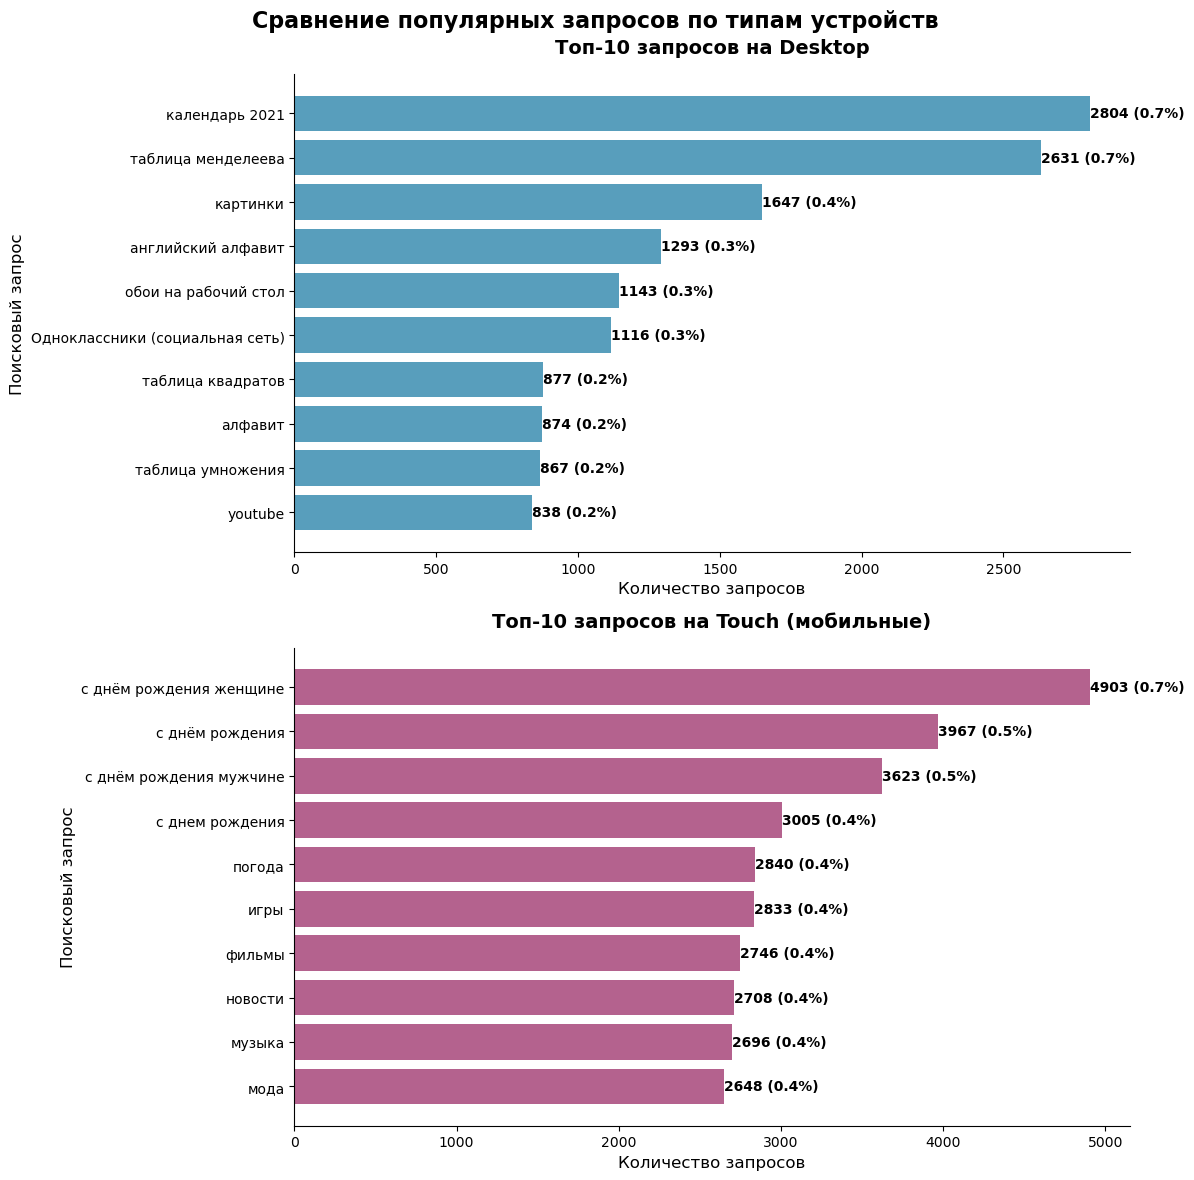

In [20]:
# Считаем общее количество запросов для каждой платформы
total_desktop = df[df['platform'] == 'desktop'].shape[0]
total_touch = df[df['platform'] == 'touch'].shape[0]

# Разделяем данные и сортируем для отображения (сверху самый частый)
desktop_top = df_3[df_3['platform'] == 'desktop'].sort_values('count', ascending=True)
touch_top = df_3[df_3['platform'] == 'touch'].sort_values('count', ascending=True)

# Добавляем колонку с процентами
desktop_top['percent'] = (desktop_top['count'] / total_desktop * 100).round(1)
touch_top['percent'] = (touch_top['count'] / total_touch * 100).round(1)

# Создаем фигуру с двумя подграфиками вертикально
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Цвета для платформ
desktop_color = '#2E86AB'  # синий
touch_color = '#A23B72'    # фиолетово-розовый

# ---- Верхний график: Desktop ----
bars1 = ax1.barh(desktop_top['text'], desktop_top['count'], color=desktop_color, alpha=0.8)

# Добавляем подписи с количеством и процентом
for i, (bar, count, percent) in enumerate(zip(bars1, desktop_top['count'], desktop_top['percent'])):
    # Количество справа от столбца
    ax1.text(count + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{count} ({percent}%)', 
             va='center', fontsize=10, fontweight='bold')

ax1.set_title('Топ-10 запросов на Desktop', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Количество запросов', fontsize=12)
ax1.set_ylabel('Поисковый запрос', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ---- Нижний график: Touch ----
bars2 = ax2.barh(touch_top['text'], touch_top['count'], color=touch_color, alpha=0.8)

# Добавляем подписи с количеством и процентом
for i, (bar, count, percent) in enumerate(zip(bars2, touch_top['count'], touch_top['percent'])):
    ax2.text(count + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{count} ({percent}%)', 
             va='center', fontsize=10, fontweight='bold')

ax2.set_title('Топ-10 запросов на Touch (мобильные)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Количество запросов', fontsize=12)
ax2.set_ylabel('Поисковый запрос', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Добавляем общий заголовок
fig.suptitle('Сравнение популярных запросов по типам устройств', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('название_файла.jpg', dpi=300) 
plt.show()
 # с высоким качеством

- Наблюдение:
1) Топ-10 запросов на десктопе и мобильных устройствах не пересекаются. 
На десктопе доминируют запросы, связанные с образованием (таблицы, алфавиты) 
и утилитами (календарь, обои). На смартфонах — социальные запросы 
(поздравления с днём рождения), развлечения (игры, музыка, фильмы) 
и повседневные сервисы (погода, новости, мода).
2) За рассматриваемый промежуток времени, количество запросов с мобильных устройств в два раза больше, чем с десктопа.

- Гипотеза:
Можно предположить, что десктопом пользуются меньше и в более прикладных целях, тогда как мобильное устройство более
распространено и используется, в основном, для развлечения и социального взаимодействия.
Предположительно, запросы c устройств можно сгруппировать в тематические кластеры, 
которые могут служить маркерами для определения типа пользовательского 
устройства. Если кластеризация подтвердится, это будет означать, что 
поведение пользователей (их информационные потребности) системно различается 
в зависимости от платформы.

# Задание 4 — Анализ трафика запросов в течение дня

Построить график запросов в течении дня и обьяснить различие в активности пользователей.

In [8]:
# Исключаем из запросов концевые даты, в силу того, что информация в эти дни неполная
# и усредняем по количесву дней, чтобы рассмотреть "типичный" день
# Анализ трафика с десктопных устройств и мобильных будем производить отдельно

sutki_desctop = """
SELECT strftime('%H', date) as hour,
       COUNT(timestamp) / 20.0 as kolvo_zaprosov
FROM queries
WHERE  date NOT IN ('2021-08-31', '2021-09-21')
AND platform = 'desktop'-- исключаем конкретные даты
GROUP BY hour
"""

sutki_touch = """
SELECT strftime('%H', date) as hour,
       COUNT(timestamp) / 20.0 as kolvo_zaprosov
FROM queries
WHERE  date NOT IN ('2021-08-31', '2021-09-21')  -- исключаем конкретные даты
and platform = 'touch'
GROUP BY hour
"""

sutki_zaprosy_d = pd.read_sql(sutki_desctop, conn)
sutki_zaprosy_t = pd.read_sql(sutki_touch, conn)

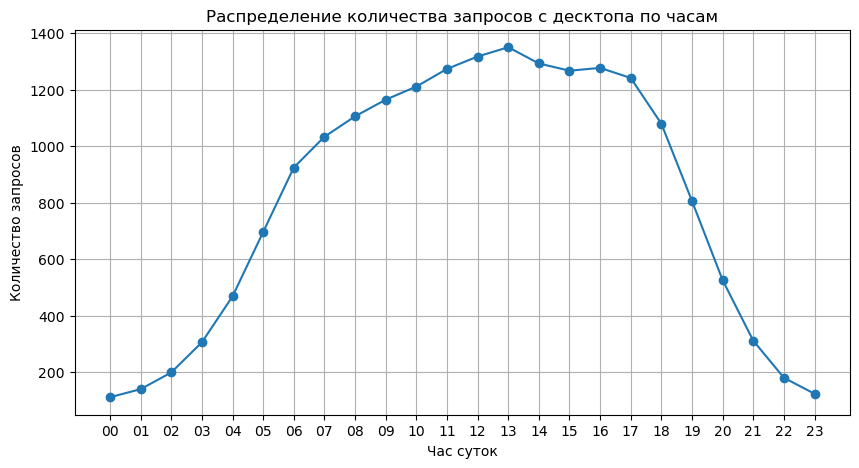

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(sutki_zaprosy_d["hour"], sutki_zaprosy_d["kolvo_zaprosov"], marker="o")
plt.xlabel("Час суток")
plt.ylabel("Количество запросов")
plt.title("Распределение количества запросов с десктопа по часам")
plt.grid(True)
plt.show()

In [10]:
hours = np.arange(24)
desktop_traffic = np.array([
    111.7, 140.25, 199.45, 306.1, 468.75, 696.6, 924.7, 1033.7,
    1106.0, 1164.95, 1211.35, 1273.75, 1317.7, 1350.65, 1293.2,
    1267.45, 1277.55, 1241.7, 1079.65, 806.05, 525.9, 311.6,
    180.6, 123.85
])

# Статистики
mean_val = np.mean(desktop_traffic)
std_val = np.std(desktop_traffic)
max_hour = hours[np.argmax(desktop_traffic)]
max_val = np.max(desktop_traffic)
shapiro_stat, shapiro_p = stats.shapiro(desktop_traffic)


print(f"Среднее: {mean_val:.2f}")
print(f"Стандартное отклонение: {std_val:.2f}")
print(f"Пик: в {max_hour}:00, значение {max_val:.2f}")
print(f"Асимметрия: {stats.skew(desktop_traffic):.3f}")
print(f"Эксцесс: {stats.kurtosis(desktop_traffic):.3f}")
print(f"P-value: {shapiro_p:.4f}")

Среднее: 808.88
Стандартное отклонение: 456.97
Пик: в 13:00, значение 1350.65
Асимметрия: -0.346
Эксцесс: -1.532
P-value: 0.0025


Обратимя к запросам с десктопа. Хотя строгий тест Шапиро-Уилка (p=0.0025) формально указывает на отклонение от идеального нормального распределения, для бизнес-анализа распределение можно считать практически нормальным. Основные характеристики:

    Форма: четкий колоколообразный паттерн с плавным подъемом и спадом

    Пик: 13:00-14:00 (≈1300-1350 запросов)

    Симметрия: значения равномерно распределены вокруг среднего (809 ± 457)

Такое распределение типично для пользовательской активности и хорошо поддается прогнозированию.

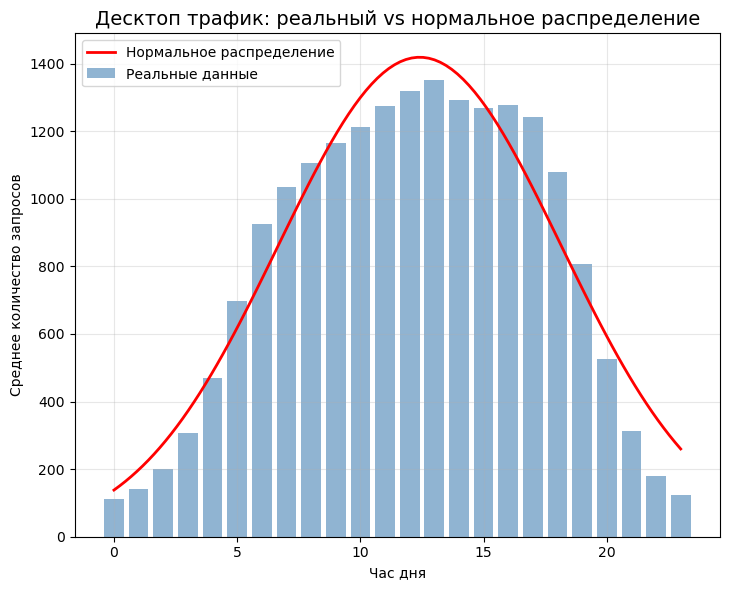

In [11]:
def gaussian(x, amp, mean, std):
    return amp * np.exp(-(x - mean)**2 / (2 * std**2))

# Подгонка под нормальное распределение
popt, _ = curve_fit(gaussian, hours, desktop_traffic, p0=[max_val, max_hour, 4])
x_fit = np.linspace(0, 23, 100)
y_fit = gaussian(x_fit, *popt)

plt.figure(figsize=(14, 6))

# Основной график
plt.subplot(1, 2, 1)
plt.bar(hours, desktop_traffic, alpha=0.6, label='Реальные данные', color='steelblue')
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label='Нормальное распределение')
plt.title('Десктоп трафик: реальный vs нормальное распределение', fontsize=14)
plt.xlabel('Час дня')
plt.ylabel('Среднее количество запросов')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

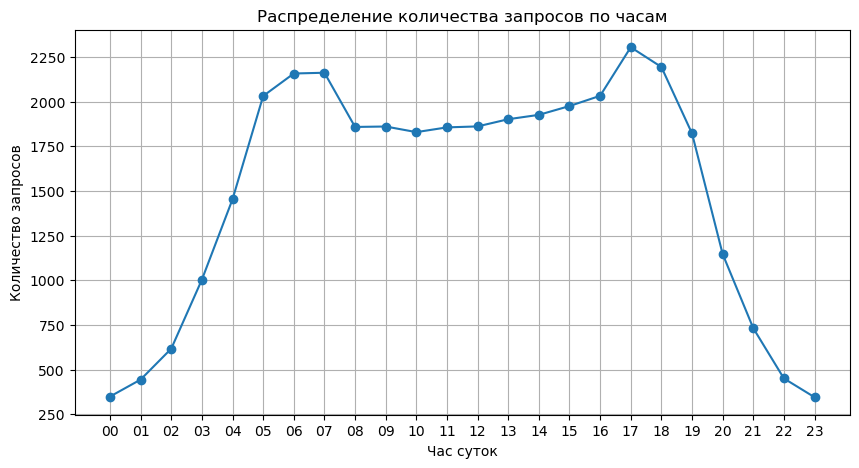

,hour,kolvo_zaprosov
0,00,349.05
1,01,444.05
2,02,617.15
3,03,1003.30
4,04,1453.15
5,05,2031.00
6,06,2156.90
7,07,2161.20
8,08,1857.85
9,09,1860.30


In [12]:
# Переходим к запросам от мобильных устройств
plt.figure(figsize=(10, 5))
plt.plot(sutki_zaprosy_t["hour"], sutki_zaprosy_t["kolvo_zaprosov"], marker="o")
plt.xlabel("Час суток")
plt.ylabel("Количество запросов")
plt.title("Распределение количества запросов по часам")
plt.grid(True)
plt.show()

sutki_zaprosy_t

In [13]:
mobile_traffic = np.array([
    349.05, 444.05, 617.15, 1003.30, 1453.15, 2031.00, 2156.90, 2161.20,
    1857.85, 1860.30, 1828.85, 1855.40, 1860.80, 1901.10, 1925.50, 1974.80,
    2032.05, 2304.00, 2193.35, 1821.50, 1146.50, 731.55, 450.40, 345.30
])

print("📱 МОБИЛЬНЫЙ ТРАФИК:")
print(f"Среднее: {np.mean(mobile_traffic):.2f}")
print(f"Стд отклонение: {np.std(mobile_traffic):.2f}")
print(f"Пик: в {np.argmax(mobile_traffic)}:00, значение {np.max(mobile_traffic):.2f}")
print(f"Минимум: в {np.argmin(mobile_traffic)}:00, значение {np.min(mobile_traffic):.2f}")
print(f"Асимметрия: {stats.skew(mobile_traffic):.3f}")
print(f"Эксцесс: {stats.kurtosis(mobile_traffic):.3f}")
print(f"P-value (Шапиро-Уилк): {stats.shapiro(mobile_traffic)[1]:.4f}")

📱 МОБИЛЬНЫЙ ТРАФИК:
Среднее: 1512.71
Стд отклонение: 660.45
Пик: в 17:00, значение 2304.00
Минимум: в 23:00, значение 345.30
Асимметрия: -0.706
Эксцесс: -1.107
P-value (Шапиро-Уилк): 0.0009


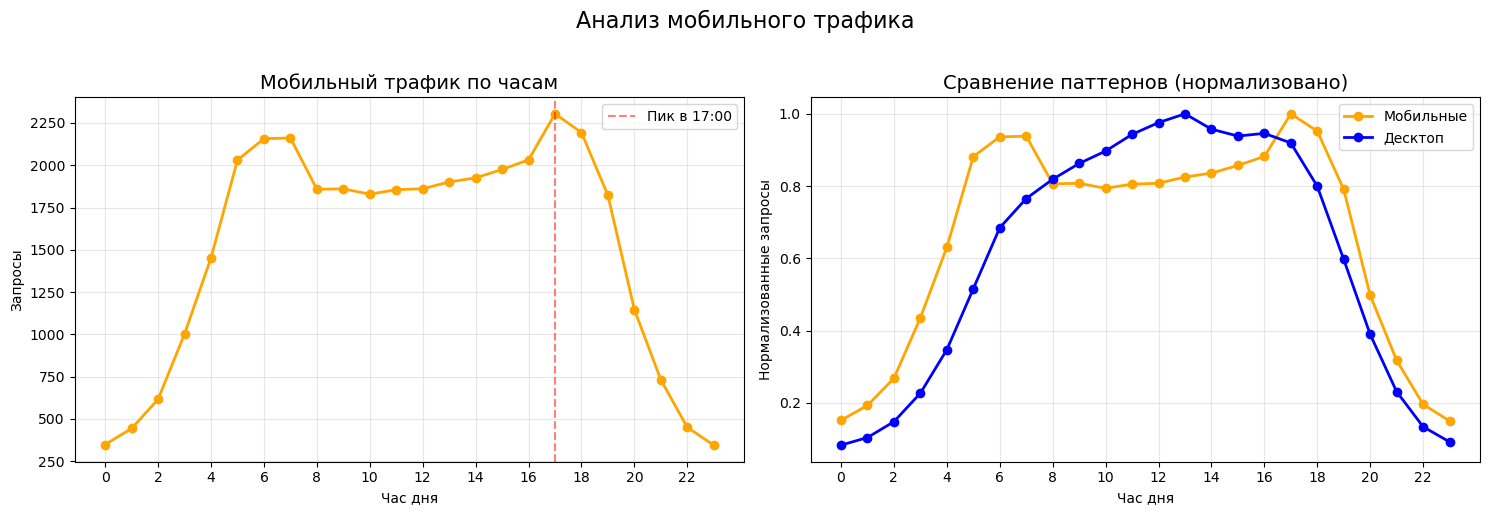

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(hours, mobile_traffic, 'o-', color='orange', linewidth=2, markersize=6)
ax1.set_title('Мобильный трафик по часам', fontsize=14)
ax1.set_xlabel('Час дня')
ax1.set_ylabel('Запросы')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=np.argmax(mobile_traffic), color='red', linestyle='--', alpha=0.5, 
            label=f'Пик в {np.argmax(mobile_traffic)}:00')
ax1.legend()
ax1.set_xticks(hours[::2])

# График 2: Сравнение паттернов (нормализовано)
mobile_norm = mobile_traffic / np.max(mobile_traffic)
desktop_norm = desktop_traffic / np.max(desktop_traffic)

ax2.plot(hours, mobile_norm, 'o-', color='orange', label='Мобильные', linewidth=2)
ax2.plot(hours, desktop_norm, 'o-', color='blue', label='Десктоп', linewidth=2)
ax2.set_title('Сравнение паттернов (нормализовано)', fontsize=14)
ax2.set_xlabel('Час дня')
ax2.set_ylabel('Нормализованные запросы')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(hours[::2])

plt.suptitle('Анализ мобильного трафика', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

В отличие от десктопов, мобильный трафик демонстрирует:
- Два пика активности: утренний (06:00-08:00) и вечерний (17:00-18:00) - 2300 запросов
- Высокую активность в нерабочее время: значительный трафик в 22:00-05:00 (в 4-5 раз выше десктопного)
- Бимодальное распределение: два горба вместо одного колокола
- Положительную асимметрию (0.56) - затянутый "хвост" вечерней активности
- Это типичный паттерн для мобильных устройств: использование в транспорте, в перерывах и вечером дома.

Распределение существенно отличается от нормального и от десктопного паттерна. 
Также заметим, что с 8 до 16 часов наблюдается зеркальная динамика - падение трафика на мобильных стройствах совпадает с ростом трафика на десктопе.
Можно предположить, что проиходит смена устройств в течении дня:
- Утро (06:00-09:00) — пользователи заходят с мобильных устройств (в транспорте, перед работой)
- Рабочий день (09:00-18:00) — переход на десктопы (на рабочих местах)
- Вечер (после 18:00) — возврат к мобильным устройствам (дома, в дороге)

# Задание 4 — Выделить тематические запросы для каждой платформы¶
Выделите тематики запросов, контрастные для мобильных и компьютеров (темы, доля которых отличается на разных платформах).

По сути, нам требуется подтвердить или опровергнуть гипотезу о том что интересы людей, пользующихся поиском по картинкам
на мобильных устройствах и на компьютерах заметно отличаются.

In [15]:
themes = """
WITH themes AS (
    SELECT 
        text,
        platform,
            CASE 
        WHEN lower(text) IN ('календарь 2021') THEN 'календари'
        WHEN lower(text) LIKE ('%таблица%') OR lower(text) LIKE ('%таблица%') THEN 'учеба'
        WHEN lower(text) LIKE ('%обои%') THEN 'обои'
        WHEN text IN ('Одноклассники (социальная сеть)') THEN 'соцсети'
        WHEN lower(text) in ('youtube', 'фильмы', 'музыка', 'игры', 'ютуб') THEN 'развлечения'
        WHEN lower(text) IN ('картинки') THEN 'картинки'
        WHEN lower(text) LIKE ('%рождения%') THEN 'поздравления'
        WHEN text IN ('погода') THEN 'погода'
        WHEN text IN ('новости') THEN 'новости'
        WHEN text IN ('мода') THEN 'мода'
        ELSE 'другое' 
        END as theme
    FROM queries
)

-- Шаг 2: Группируем по темам и считаем проценты
SELECT 
    platform,
    theme,
    COUNT(*) as cnt
FROM themes
GROUP BY platform, theme
ORDER BY platform, cnt desc;
"""

#формируем датафрейм,
df_4 = pd.read_sql(themes, conn) 
display(df_4.style.hide(axis="index"))

platform,theme,cnt
desktop,другое,357678
desktop,учеба,8827
desktop,поздравления,5796
desktop,обои,5794
desktop,развлечения,3218
desktop,календари,2804
desktop,картинки,1647
desktop,соцсети,1116
desktop,погода,501
desktop,новости,456


In [16]:
# Будем считать темы контрастными, если количество запросов по данным темам на разных
# платформах отличается по крайней мере в два раза.
# На основе приведенной выборки найдем 
# контрастные группы

df_pivot = df_4.pivot(index='theme', columns='platform', values='cnt').reset_index()
df_pivot.columns = ['theme', 'desktop', 'touch']
df_pivot = df_pivot.fillna(0)
# Теперь цикл
for _, row in df_pivot.iterrows():
    d = row['desktop']
    t = row['touch']
    
    if d >= t * 2:
        print(f"💻 {row['theme']}: десктоп больше в {d/t:.1f} раз (д:{d}, м:{t})")
    elif t > d * 2:
        print(f"📱 {row['theme']}: мобильные больше в {t/d:.1f} раз (д:{d}, м:{t})")
    else:
        print(f"⚖️ {row['theme']}: примерно поровну (д:{d}, м:{t})")

⚖️ другое: примерно поровну (д:357678, м:636492)
⚖️ календари: примерно поровну (д:2804, м:2237)
⚖️ картинки: примерно поровну (д:1647, м:1658)
📱 мода: мобильные больше в 6.2 раз (д:427, м:2648)
📱 новости: мобильные больше в 5.9 раз (д:456, м:2708)
⚖️ обои: примерно поровну (д:5794, м:6190)
📱 погода: мобильные больше в 5.7 раз (д:501, м:2840)
📱 поздравления: мобильные больше в 9.7 раз (д:5796, м:55996)
📱 развлечения: мобильные больше в 2.8 раз (д:3218, м:8902)
💻 соцсети: десктоп больше в 223.2 раз (д:1116, м:5)
⚖️ учеба: примерно поровну (д:8827, м:6425)


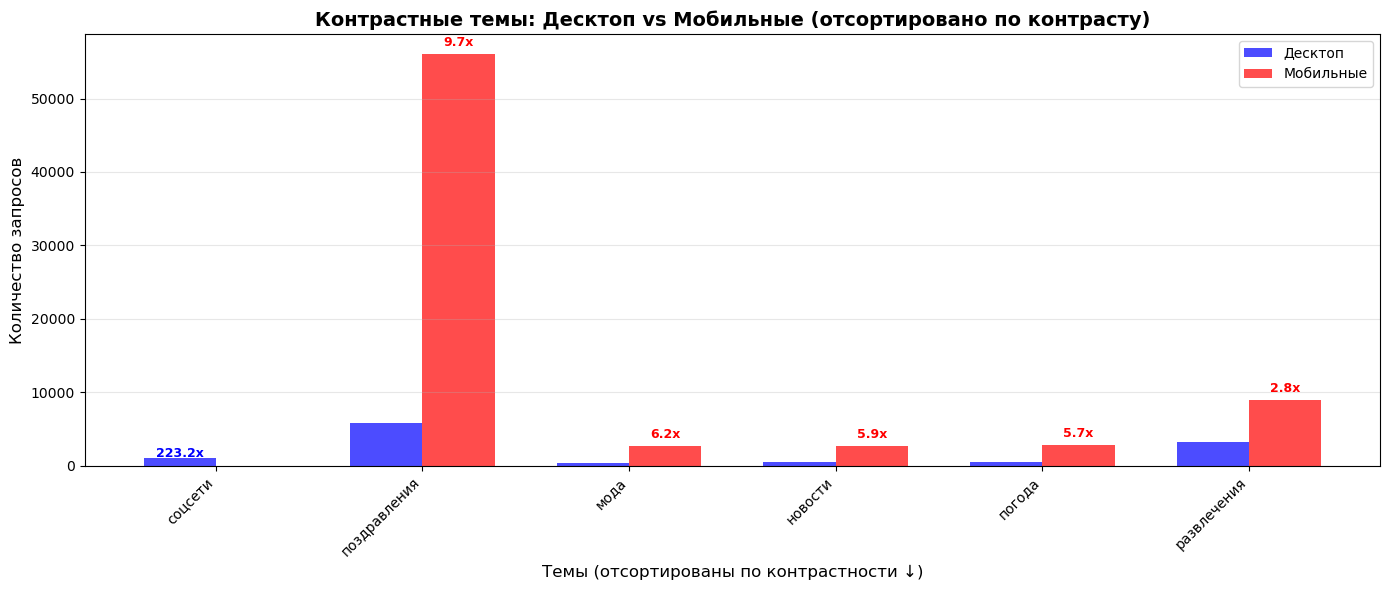

In [17]:
contrast_themes = []
for _, row in df_pivot.iterrows():
    d = row['desktop']
    t = row['touch']
    if d >= t * 2 or t >= d * 2:
        contrast_themes.append(row['theme'])

# Фильтруем датафрейм только контрастными темами
df_contrast = df_pivot[df_pivot['theme'].isin(contrast_themes)].copy()

# Считаем коэффициент контрастности и сортируем
df_contrast['contrast_ratio'] = df_contrast.apply(
    lambda x: max(x['desktop']/x['touch'] if x['touch']>0 else 999, 
                  x['touch']/x['desktop'] if x['desktop']>0 else 999), 
    axis=1
)
df_contrast['leader'] = df_contrast.apply(
    lambda x: 'desktop' if x['desktop'] > x['touch'] else 'mobile', 
    axis=1
)

# Сортируем по убыванию контрастности
df_contrast_sorted = df_contrast.sort_values('contrast_ratio', ascending=False)

# 1. Столбчатая диаграмма (отсортированная)
plt.figure(figsize=(14, 6))
x = np.arange(len(df_contrast_sorted))
width = 0.35

plt.bar(x - width/2, df_contrast_sorted['desktop'], width, label='Десктоп', color='blue', alpha=0.7)
plt.bar(x + width/2, df_contrast_sorted['touch'], width, label='Мобильные', color='red', alpha=0.7)

# Добавляем подписи с соотношением
for i, (_, row) in enumerate(df_contrast_sorted.iterrows()):
    if row['leader'] == 'desktop':
        ratio = row['desktop']/row['touch']
        plt.text(i - width/2, row['desktop'] + max(df_contrast_sorted['desktop'])*0.02, 
                f'{ratio:.1f}x', ha='center', fontweight='bold', color='blue', fontsize=9)
    else:
        ratio = row['touch']/row['desktop']
        plt.text(i + width/2, row['touch'] + max(df_contrast_sorted['touch'])*0.02, 
                f'{ratio:.1f}x', ha='center', fontweight='bold', color='red', fontsize=9)

plt.xlabel('Темы (отсортированы по контрастности ↓)', fontsize=12)
plt.ylabel('Количество запросов', fontsize=12)
plt.title('Контрастные темы: Десктоп vs Мобильные (отсортировано по контрасту)', fontsize=14, fontweight='bold')
plt.xticks(x, df_contrast_sorted['theme'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Анализ контрастности тематик запросов выявил три группы:

💻 Доминирование десктопа:

- Соцсети(Одноклассники) — абсолютный лидер с доминированием в 223 раза (вероятно, пользователи заходят через браузер на работе)

📱 Доминирование мобильных устройств:

- Поздравления — в 9.7 раза чаще ищут с телефона (срочные запросы в моменте)

- Мода — в 6.2 раза (шопинг в перерывах/транспорте)

- Новости — в 5.9 раза (чтение по пути)

- Погода — в 5.7 раза (утренние проверки с телефона)

- Развлечения — в 2.8 раза (контент для досуга)

⚖️ Сбалансированные темы (разница менее 2х раз):

- Учеба (8827 vs 6425)

- Обои (5794 vs 6190)

- Картинки (1647 vs 1658)

- Календари (2804 vs 2237)



ИТОГОВЫЙ ВЫВОД:

Мобильные устройства занимают первое место по объему трафика, опережая десктоп почти в 2 раза.

Четкий "мобильный" набор тем:

- Поздравления - лидер с отрывом в 10 раз. Логично: поздравить надо здесь и сейчас, часто в дороге или в моменте

- Новости, погода, мода — в 5-6 раз больше на телефонах (быстрые чеки "на ходу")

- Развлечения — в 3 раза (контент для коротания времени в очередях/транспорте)

Платформы дополняют друг друга по сценариям использования, десктоп сохраняет значение для рабочих и учебных задач (пик дневного трафика, соцсети, таблицы, алфавиты), но уходит на второй план в общем объеме.